Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9287 - loss: 0.2513 - val_accuracy: 0.9634 - val_loss: 0.1230
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9678 - loss: 0.1081 - val_accuracy: 0.9709 - val_loss: 0.0951
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9778 - loss: 0.0747 - val_accuracy: 0.9758 - val_loss: 0.0826
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9836 - loss: 0.0548 - val_accuracy: 0.9762 - val_loss: 0.0812
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9868 - loss: 0.0421 - val_accuracy: 0.9760 - val_loss: 0.0819
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9900 - loss: 0.0336 - val_accuracy: 0.9773 - val_loss: 0.0760
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9918 - loss: 0.0262 - val_accuracy: 0.9778 - val_loss: 0.0765
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9930 - loss: 0.022

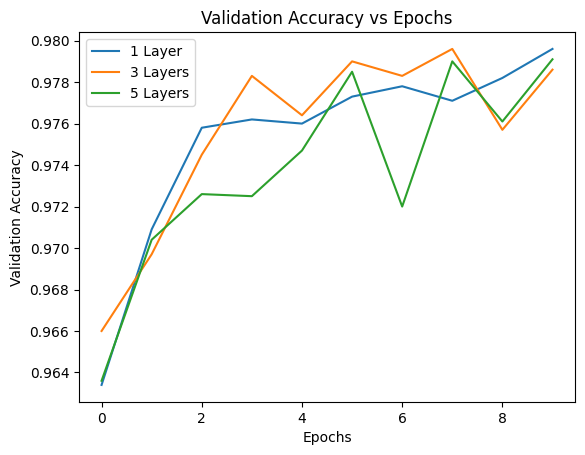

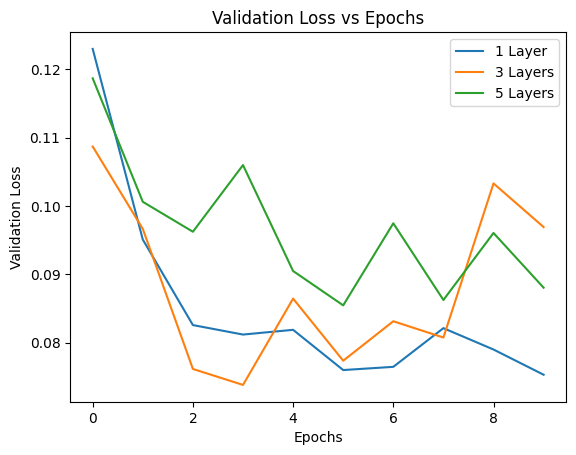

Final Results:
1 Layer -> Accuracy: 0.9796, Loss: 0.0753
3 Layers -> Accuracy: 0.9786, Loss: 0.0969
5 Layers -> Accuracy: 0.9791, Loss: 0.0881


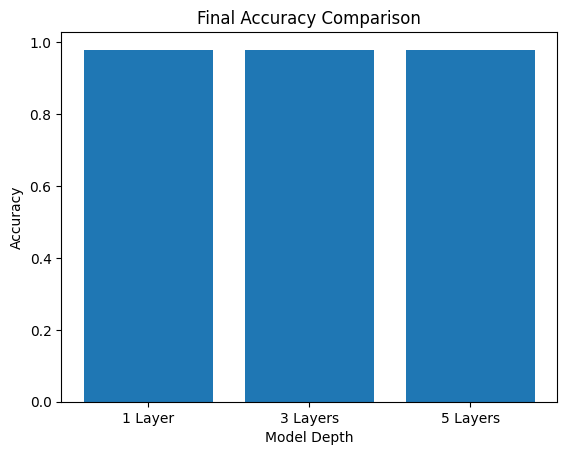

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical


(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)


def build_model(depth):
    model = Sequential()
    model.add(Flatten(input_shape=(28, 28)))

    for _ in range(depth):
        model.add(Dense(128, activation='relu'))

    model.add(Dense(10, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model_1 = build_model(1)   # shallow
model_3 = build_model(3)   # medium
model_5 = build_model(5)   # deep


epochs = 10

history_1 = model_1.fit(x_train, y_train, epochs=epochs, validation_data=(x_test, y_test), verbose=1)
history_3 = model_3.fit(x_train, y_train, epochs=epochs, validation_data=(x_test, y_test), verbose=1)
history_5 = model_5.fit(x_train, y_train, epochs=epochs, validation_data=(x_test, y_test), verbose=1)


plt.figure()
plt.plot(history_1.history['val_accuracy'], label='1 Layer')
plt.plot(history_3.history['val_accuracy'], label='3 Layers')
plt.plot(history_5.history['val_accuracy'], label='5 Layers')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy vs Epochs')
plt.legend()
plt.show()



plt.figure()
plt.plot(history_1.history['val_loss'], label='1 Layer')
plt.plot(history_3.history['val_loss'], label='3 Layers')
plt.plot(history_5.history['val_loss'], label='5 Layers')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.title('Validation Loss vs Epochs')
plt.legend()
plt.show()


loss1, acc1 = model_1.evaluate(x_test, y_test, verbose=0)
loss3, acc3 = model_3.evaluate(x_test, y_test, verbose=0)
loss5, acc5 = model_5.evaluate(x_test, y_test, verbose=0)

print("Final Results:")
print(f"1 Layer -> Accuracy: {acc1:.4f}, Loss: {loss1:.4f}")
print(f"3 Layers -> Accuracy: {acc3:.4f}, Loss: {loss3:.4f}")
print(f"5 Layers -> Accuracy: {acc5:.4f}, Loss: {loss5:.4f}")


models = ['1 Layer', '3 Layers', '5 Layers']
accuracies = [acc1, acc3, acc5]

plt.figure()
plt.bar(models, accuracies)
plt.xlabel('Model Depth')
plt.ylabel('Accuracy')
plt.title('Final Accuracy Comparison')
plt.show()

##Guithub Link : https://github.com/ekanth3128/Exploring-the-Impact-of-Network-Depth-on-Neural-Network-Performance-/edit/main